In [ ]:
from rasterio.transform import from_bounds
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from inference_engine import InferenceEngine, predict_with_confidence
from pathlib import Path
import matplotlib.colors as mcolors
import rasterio
import os
from rasterio.transform import Affine
import pandas as pd
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import geopandas as gpd
from shapely.geometry import box


# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#C6DBEF', 2: '#6BAED6', 3: '#2171B5', 4: '#08306B'}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

# Mask -1 values so they render as fully transparent
flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_cmap.set_bad(alpha=0)                          # -1 → transparent
legend_patches = [mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)]
flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

# ── GeoTIFF save helper ───────────────────────────────────────────────────────
src_left, src_top   = 13457490.0, 1664610.0
src_W,    src_H     = 1125,       1224          # original size
dst_W,    dst_H     = 1152,       1152          # resampled size
src_right           = 13491240.0
src_bottom          = 1627890.0

new_pixel_x = (src_right  - src_left) / dst_W   # 33750 / 1152 = 29.296875
new_pixel_y = (src_bottom - src_top)  / dst_H   # -36720 / 1152 = -31.875

dem_transform = Affine(new_pixel_x, 0.0, src_left, 0.0, new_pixel_y, src_top)
dem_crs       = rasterio.crs.CRS.from_epsg(3857)
_H, _W        = 1152, 1152

# ── Barangay band: reprojected ONCE onto dem_transform/dem_crs grid ──────────
def compute_class_pcts(flood_map):
    valid = flood_map[flood_map >= 0]
    total = len(valid)
    return {i: 100 * (valid == i).sum() / total if total > 0 else 0.0
            for i in range(5)}

def _load_barangay_band_from_geojson(geojson_path, dst_transform, dst_crs, H, W):
    gdf = gpd.read_file(geojson_path)
    gdf = gdf.to_crs(dst_crs)
    gdf = gdf.dropna(subset=['psgc_code']).copy()

    # ── Drop null/empty/invalid geometries ───────────────────────────────────
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna() & gdf.geometry.is_valid]

    gdf['psgc_int'] = gdf['psgc_code'].astype(float).astype(int)

    # ── Clip to DEM grid extent ───────────────────────────────────────────────
    left   = dst_transform.c
    top    = dst_transform.f
    right  = left + dst_transform.a * W
    bottom = top  + dst_transform.e * H
    grid_box = box(left, min(top, bottom), right, max(top, bottom))
    gdf = gdf[gdf.geometry.intersects(grid_box)]

    print(f"  Rasterizing {len(gdf)} barangays within DEM extent ...")

    shapes = [
        (geom, psgc)
        for geom, psgc in zip(gdf.geometry, gdf['psgc_int'])
        if geom is not None and not geom.is_empty
    ]

    band = rasterize(
        shapes,
        out_shape   = (H, W),
        transform   = dst_transform,
        fill        = 0,
        dtype       = 'int32',
        all_touched = True,
    )
    return band

def save_prediction_tiff(result, engine, save_path: str):
    flood_map  = result['flood_map'].astype(np.float32)
    confidence = result['confidence']

    conf_map = np.full(flood_map.shape, fill_value=-1.0, dtype=np.float32)
    for conf_val, (r, c) in zip(confidence, engine.patch_indices):
        conf_map[r:r + 4, c:c + 4] = float(conf_val)

    H, W = flood_map.shape

    # Single 3-band int32 file — all bands spatially aligned
    with rasterio.open(
        save_path, 'w',
        driver    = 'GTiff',
        height    = H, width = W,
        count     = 3,
        dtype     = 'int32',
        crs       = dem_crs,
        transform = dem_transform,
        nodata    = -1,
    ) as dst:
        dst.write(flood_map.astype(np.int32),          1)  
        dst.write((conf_map * 1000).astype(np.int32),  2)   
        dst.write(_barangay_band.astype(np.int32),     3)   
        dst.update_tags(
            BAND_1      = 'Flood class (0=No Flood 1=Light 2=Moderate 3=Heavy 4=Extreme)',
            BAND_2      = 'Confidence x1000 (divide by 1000 to get 0.0-1.0)',
            BAND_3      = 'Barangay PSGC Code',
            STORM_LABEL = result.get('storm_label', ''),
        )

    print(f"✓ Saved → {save_path}")
    
def visualize_prediction_tiff(tiff_path: str, title: str = None, figsize=(15, 4)):
    with rasterio.open(tiff_path) as src:
        flood_map = src.read(1).astype(np.float32)
        conf_map  = src.read(2).astype(np.float32) / 1000.0
        bar_map   = src.read(3) if src.count >= 3 else None
        transform = src.transform
        bounds    = src.bounds

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    nodata_mask = flood_map < 0

    # Zoom to valid flood pixels
    valid_rows, valid_cols = np.where(~nodata_mask)
    if len(valid_rows):
        pad = 20
        r0, r1 = max(valid_rows.min()-pad, 0), min(valid_rows.max()+pad, flood_map.shape[0]-1)
        c0, c1 = max(valid_cols.min()-pad, 0), min(valid_cols.max()+pad, flood_map.shape[1]-1)
        xlim = (transform.c + c0*transform.a, transform.c + c1*transform.a)
        ylim = (transform.f + r1*transform.e, transform.f + r0*transform.e)
    else:
        xlim = (bounds.left, bounds.right)
        ylim = (bounds.bottom, bounds.top)

    flood_masked = np.ma.masked_where(nodata_mask, flood_map)
    conf_masked  = np.ma.masked_where(nodata_mask, conf_map)

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(title or tiff_path, fontsize=11, fontweight='bold', y=1.02)

    # ── Band 1: Flood Class ───────────────────────────────────────────────────
    cmap_flood = mcolors.ListedColormap(['#FFFFFF','#C6DBEF','#6BAED6','#2171B5','#08306B'])
    cmap_flood.set_bad(alpha=0)
    norm_flood = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], 5)

    axes[0].imshow(flood_masked, cmap=cmap_flood, norm=norm_flood,
                   extent=extent, interpolation='nearest', aspect='equal')
    axes[0].set_xlim(*xlim); axes[0].set_ylim(*ylim)
    axes[0].set_title('Flood Class', fontsize=9, fontweight='bold')
    axes[0].tick_params(labelsize=6)

    patches = [mpatches.Patch(color=c, label=l) for c, l in zip(
        ['#FFFFFF','#C6DBEF','#6BAED6','#2171B5','#08306B'],
        ['No Flood','Light','Moderate','Heavy','Extreme'])]
    axes[0].legend(handles=patches, loc='lower right', fontsize=6, framealpha=0.8)

    # ── Band 2: Confidence ────────────────────────────────────────────────────
    cmap_conf = plt.cm.RdYlGn.copy(); cmap_conf.set_bad(alpha=0)
    im2 = axes[1].imshow(conf_masked, cmap=cmap_conf, vmin=0, vmax=1,
                          extent=extent, interpolation='nearest', aspect='equal')
    axes[1].set_xlim(*xlim); axes[1].set_ylim(*ylim)
    axes[1].set_title('Confidence', fontsize=9, fontweight='bold')
    axes[1].tick_params(labelsize=6)

    cb2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    cb2.ax.tick_params(labelsize=6)
    cb2.ax.axhline(y=0.5, color='black', linewidth=1, linestyle='--')

    # Uncertain overlay
    unc = np.where(~nodata_mask & (conf_map < 0.5), 1.0, np.nan)
    axes[1].imshow(unc, cmap='cool', alpha=0.3, vmin=0, vmax=1,
                   extent=extent, interpolation='nearest', aspect='equal')

    valid_conf = conf_map[~nodata_mask]
    axes[1].text(0.02, 0.02,
                 f"μ={valid_conf.mean():.2f}  σ={valid_conf.std():.2f}\n"
                 f"Uncertain: {(valid_conf<0.5).mean()*100:.1f}%",
                 transform=axes[1].transAxes, fontsize=6, va='bottom',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='lightgray', alpha=0.85))

    # ── Band 3: Barangay ─────────────────────────────────────────────────────
    if bar_map is not None:
        bar_masked   = np.ma.masked_equal(bar_map, 0)
        unique_codes = np.unique(bar_map[bar_map > 0])
        cmap_bar     = plt.cm.get_cmap('tab20', max(len(unique_codes), 1))
        cmap_bar.set_bad(color='white')

        axes[2].imshow(bar_masked, cmap=cmap_bar,
                       extent=extent, interpolation='nearest', aspect='equal')

        bar_rows, bar_cols = np.where(bar_map > 0)
        if len(bar_rows):
            bpad = 20
            br0, br1 = max(bar_rows.min()-bpad,0), min(bar_rows.max()+bpad, bar_map.shape[0]-1)
            bc0, bc1 = max(bar_cols.min()-bpad,0), min(bar_cols.max()+bpad, bar_map.shape[1]-1)
            axes[2].set_xlim(transform.c + bc0*transform.a, transform.c + bc1*transform.a)
            axes[2].set_ylim(transform.f + br1*transform.e, transform.f + br0*transform.e)
        else:
            axes[2].set_xlim(*xlim); axes[2].set_ylim(*ylim)

        axes[2].set_title(f'Barangays ({len(unique_codes)})', fontsize=9, fontweight='bold')
        axes[2].tick_params(labelsize=6)
        axes[2].text(0.02, 0.02, f"{len(unique_codes)} barangay(s)",
                     transform=axes[2].transAxes, fontsize=6, va='bottom',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='lightgray', alpha=0.85))
    else:
        axes[2].axis('off')
        axes[2].set_title('Barangay (N/A)', fontsize=9)

    plt.tight_layout()
    return fig


In [2]:
_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_H, _W         = 1152, 1152

_barangay_band = _load_barangay_band_from_geojson(_GEOJSON_PATH, dem_transform, dem_crs, _H, _W)
print(f"  Barangay band ready  : {_barangay_band.shape}"
      f"  | {len(np.unique(_barangay_band[_barangay_band > 0]))} barangays"
      f"  | coverage {100*(_barangay_band > 0).mean():.1f}%")

  Rasterizing 1011 barangays within DEM extent ...
  Barangay band ready  : (1152, 1152)  | 1009 barangays  | coverage 5.4%


C:\Users\mikos\AppData\Local\Temp\ipykernel_40380\1522445657.py:59: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna() & gdf.geometry.is_valid]


In [3]:
import os, glob

tif_files = glob.glob('outputs/predictions/*.tif')

for tif_path in tif_files:
    with rasterio.open(tif_path, 'r+') as dst:
        # Sanity check — skip if Band 3 already has data
        existing = dst.read(3)
        if (existing > 0).mean() > 0.01:
            print(f'  SKIP (already has data): {tif_path}')
            continue
        
        dst.write(_barangay_band.astype(np.int32), 3)
        print(f'  ✓ Patched Band 3: {tif_path}')

print('Done.')

Done.


[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4610)
[InferenceEngine] Model loaded  ← fold_1_best.pth

  Predicting: Front-Loaded, 20 mm
  Conditioning: pattern_type=0  depth_norm=0.205  tpeak=0.00  has_tpeak=0

  Flooded area : 5.5%  (332 / 6,075 patches)
  Mean confidence : 0.671

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        5,743   94.5%      0.685
  Light               6    0.1%      0.355
  Moderate           66    1.1%      0.381
  Heavy             149    2.5%      0.378
  Extreme           111    1.8%      0.521
✓ Saved → outputs\predictions\front_loaded_20mm.tif
  ✓ front_loaded_20mm

  Predicting: Front-Loaded, 35 mm
  Conditioning: pattern_type=0  depth_norm=0.411  tpeak=0.00  has_tpeak=0

  Flooded area : 31.5%  (1,916 / 6,075 patches)
  Mean confidence : 0.638

  Class       

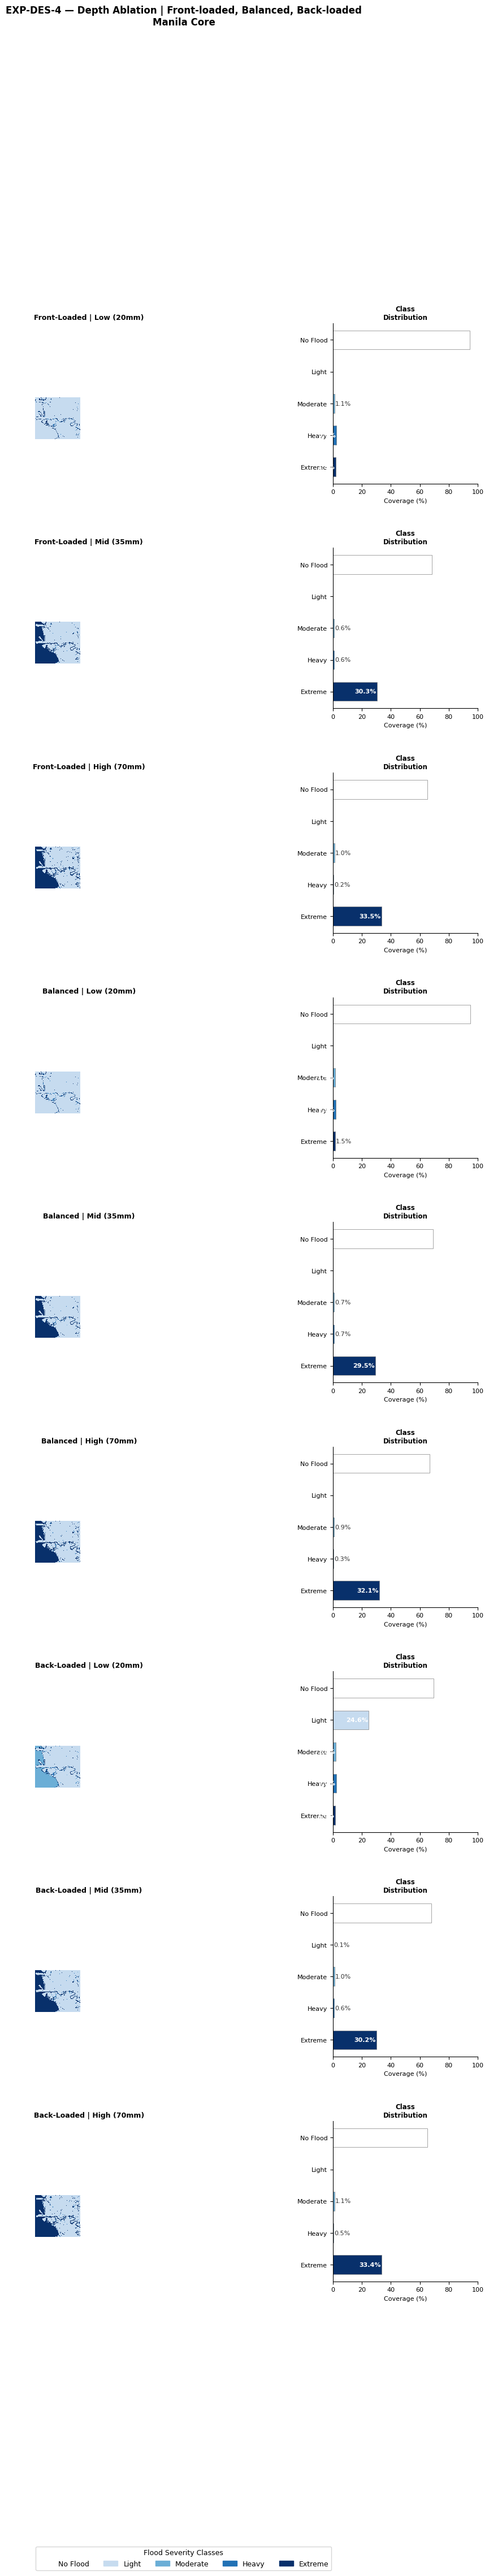

✓ Figure 1 saved


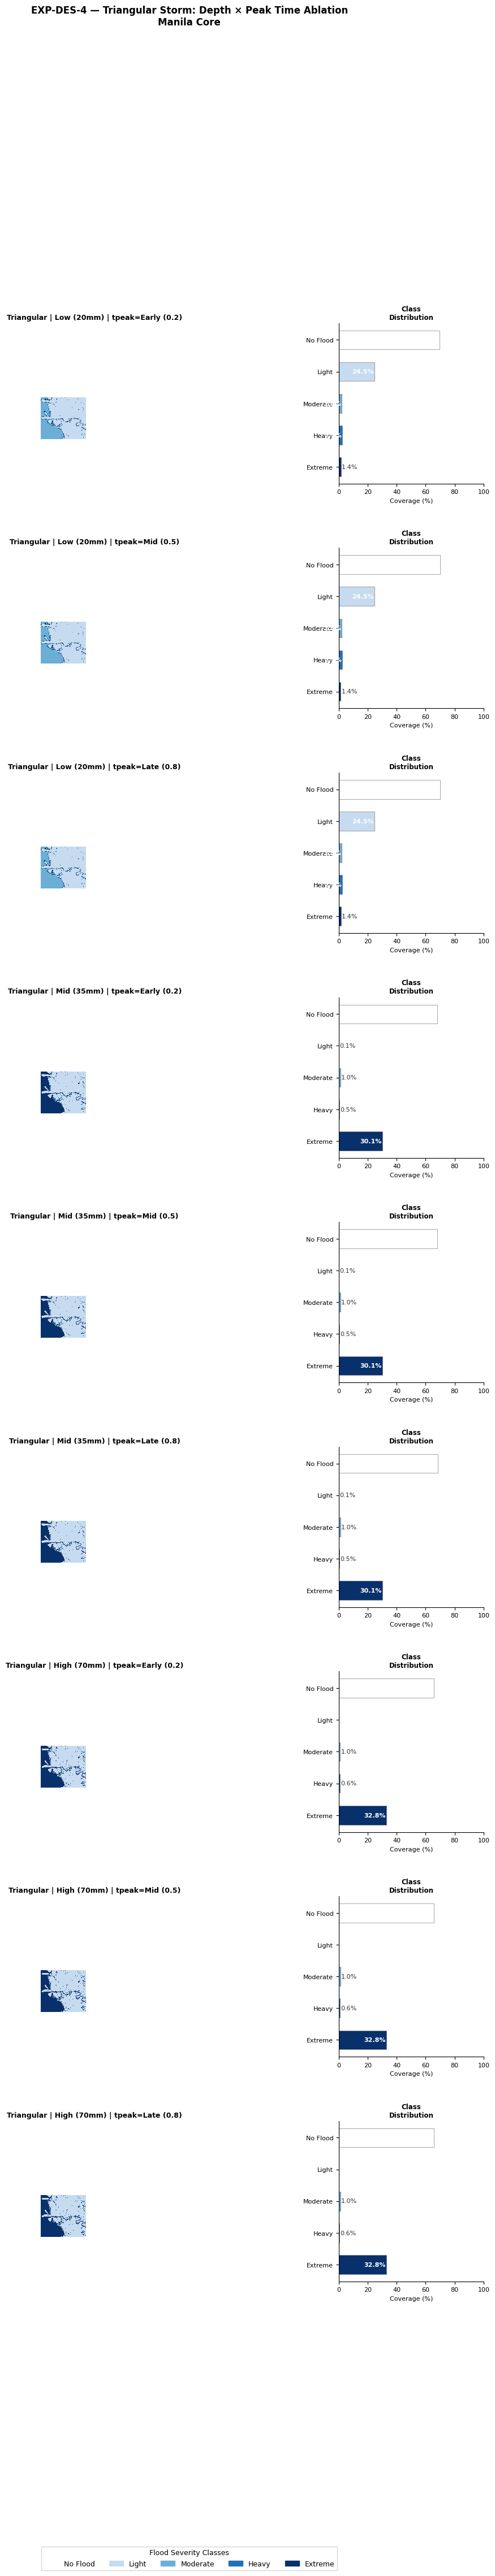

✓ Figure 2 saved

DEPTH / TPEAK ABLATION SUMMARY

  Front-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6708       30.7%     94.5%    0.1%   1.1%    2.5%      1.8%
  Mid (35mm)         0.6377       29.3%     68.5%    0.0%   0.6%    0.6%     30.3%
  High (70mm)        0.5669       47.6%     65.3%    0.0%   1.0%    0.2%     33.5%

  Balanced
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6732       30.7%     94.9%    0.1%   1.5%    1.9%      1.5%
  Mid (35mm)         0.6494       29.1%     69.1%    0.1%   0.7%    0.7%     29.5%
  High (70mm)        0.5903       32.7%     66.7%    0.0%   0.9%    0.3%     32.1%

  Back-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%

In [4]:
engine = InferenceEngine(patch_data_path = 'outputs/test_patches.npz')

# ══════════════════════════════════════════════════════════════════════════════
# DEPTH & TPEAK ABLATION — ALL 4 STORM TYPES
#
# Depth levels chosen to span the training range (6mm–78mm):
#   Low  : ~20mm  (light rainfall, near training minimum)
#   Mid  : ~35mm  (moderate, well-represented in all storm types)
#   High : ~70mm  (heavy, near training maximum)
#
# Triangular also varies tpeak: 0.2 (early), 0.5 (mid), 0.8 (late)
# giving a 3×3 grid of depth × tpeak for that storm type.
# ══════════════════════════════════════════════════════════════════════════════

DEPTHS  = [20, 35, 70]
TPEAKS  = [0.2, 0.5, 0.8]

DEPTH_LABELS = {20: 'Low (20mm)', 35: 'Mid (35mm)', 70: 'High (70mm)'}
TPEAK_LABELS = {0.2: 'Early (0.2)', 0.5: 'Mid (0.5)', 0.8: 'Late (0.8)'}

output_dir = Path('outputs/predictions')
output_dir.mkdir(parents=True, exist_ok=True)

# ── Storage ───────────────────────────────────────────────────────────────────
results_depth = {st: {} for st in ['front-loaded', 'balanced', 'back-loaded']}
results_tri   = {d:  {} for d  in DEPTHS}

# ── Run predictions ───────────────────────────────────────────────────────────
# Non-triangular: depth ablation only
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result = predict_with_confidence(
            engine, storm_type=storm_type, depth_mm=depth
        )
        results_depth[storm_type][depth] = result
        slug = f"{storm_type.replace('-','_')}_{depth}mm"
        save_prediction_tiff(result, engine, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

# Triangular: depth × tpeak grid
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result = predict_with_confidence(
            engine, storm_type='triangular', depth_mm=depth, tpeak=tpeak
        )
        results_tri[depth][tpeak] = result
        slug = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        save_prediction_tiff(result, engine, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

print(f'\n✓ All predictions saved → {output_dir}')

# ── Figure 1: Depth ablation — front-loaded, balanced, back-loaded ────────────
# Layout: 3 storm types × 3 depths = 9 rows, 2 cols (flood map | bar)
fig1, axes1 = plt.subplots(9, 2, figsize=(13, 45), gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25})
row = 0
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result   = results_depth[storm_type][depth]
        ax_flood = axes1[row, 0]
        ax_bar   = axes1[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(f'{storm_type.title()} | {DEPTH_LABELS[depth]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig1.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig1.suptitle(
    'EXP-DES-4 — Depth Ablation | Front-loaded, Balanced, Back-loaded\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_depth_non_triangular.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 1 saved')


# ── Figure 2: Triangular depth × tpeak grid ───────────────────────────────────
# Layout: 9 combos (3 depths × 3 tpeaks) rows, 2 cols (flood map | bar)
fig2, axes2 = plt.subplots(
    9, 2, figsize=(13, 45),
    gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25}
)
row = 0
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result   = results_tri[depth][tpeak]
        ax_flood = axes2[row, 0]
        ax_bar   = axes2[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(
            f'Triangular | {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig2.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig2.suptitle(
    'EXP-DES-4 — Triangular Storm: Depth × Peak Time Ablation\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_triangular_depth_tpeak.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 2 saved')


# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '='*75)
print('DEPTH / TPEAK ABLATION SUMMARY')
print('='*75)

# Non-triangular
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    print(f'\n  {storm_type.title()}')
    print(f'  {"Depth":<16} {"AvgConf":>8} {"Uncertain%":>11} '
          f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
    print(f'  {"-"*78}')
    for depth in DEPTHS:
        result      = results_depth[storm_type][depth]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        print(f'  {DEPTH_LABELS[depth]:<16} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

# Triangular
print(f'\n  Triangular')
print(f'  {"Depth × tpeak":<22} {"AvgConf":>8} {"Uncertain%":>11} '
      f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
print(f'  {"-"*84}')
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result      = results_tri[depth][tpeak]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        label       = f'{DEPTH_LABELS[depth]} | tp={tpeak}'
        print(f'  {label:<22} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

In [5]:
import geopandas as gpd

_GEOJSON_PATH = 'manila_barangay_geojson.geojson'

_CITY_LABEL = {
    'PH1303901': 'Manila City',
    'PH1307401': 'Mandaluyong',
    'PH1307404': 'Marikina',
    'PH1307405': 'Pasig',
    'PH1307501': 'Las Piñas',
    'PH1307503': 'Parañaque',
    'PH1307602': 'San Juan',
    'PH1307605': 'Taguig',
}

def _build_barangay_lookup(geojson_path: str) -> dict:
    gdf = gpd.read_file(geojson_path)
    gdf['adm3_pcode'] = gdf['adm3_pcode'].astype(str)

    gdf_all = gdf.dropna(subset=['psgc_code']).copy()
    gdf_all['psgc_int'] = gdf_all['psgc_code'].astype(float).astype(int)

    lookup = {}
    for _, row in gdf_all.iterrows():
        psgc = int(row['psgc_int'])
        city = _CITY_LABEL.get(str(row['adm3_pcode']), str(row['adm3_pcode']))
        
        name = row['adm4_en'] if pd.notna(row['adm4_en']) else f'Barangay (PSGC {psgc})'

        lookup[psgc] = {
            'name'      : name,
            'city'      : city,
            'adm4_pcode': row['adm4_pcode'] if pd.notna(row.get('adm4_pcode')) else '',
            'adm3_pcode': row['adm3_pcode'],
            'area_sqkm' : float(row['shape_sqkm']) if pd.notna(row.get('shape_sqkm')) else 0.0,
        }
    return lookup

BARANGAY_LOOKUP = _build_barangay_lookup(_GEOJSON_PATH)

print(f'BARANGAY_LOOKUP ready  : {len(BARANGAY_LOOKUP):,} entries')
print(f'PSGC range             : {min(BARANGAY_LOOKUP):,} – {max(BARANGAY_LOOKUP):,}')
print(f'Cities                 : {sorted(set(v["city"] for v in BARANGAY_LOOKUP.values()))}')


BARANGAY_LOOKUP ready  : 4,560 entries
PSGC range             : 330,100,001 – 1,999,908,008
Cities                 : ['Las Piñas', 'Mandaluyong', 'Manila City', 'Marikina', 'None', 'Parañaque', 'Pasig', 'San Juan', 'Taguig']


In [6]:
import numpy as np
import rasterio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

"""
def _build_hover_arrays(flood_map, conf_x1000_map, bar_map):
    H, W       = flood_map.shape
    valid_mask = flood_map >= 0

    flood_disp = np.where(valid_mask, flood_map.astype(float), np.nan)
    conf_disp  = np.where(valid_mask, conf_x1000_map.astype(float) / 1000.0, np.nan)

    # Build hover text — empty string for nodata pixels (they won't be hovered)
    hover_text = np.full((H, W), '', dtype=object)

    rows, cols = np.where(valid_mask)
    for r, c in zip(rows, cols):
        info = resolve_pixel(
            flood_class = int(flood_map[r, c]),
            conf_x1000  = int(conf_x1000_map[r, c]),
            psgc_code   = int(bar_map[r, c]),
        )
        hover_text[r, c] = (
            f"<b>Hazard</b>: {info['flood_label']} (class {info['flood_class']})<br>"
            f"<b>Confidence</b>: {info['conf_pct']}<br>"
            f"<b>Barangay</b>: {info['barangay']}<br>"
            f"<b>City</b>: {info['city']}<br>"
            f"<sub>PSGC {info['psgc']}  |  ADM4 {info['adm4_pcode']}</sub>"
        )

    return hover_text, flood_disp, conf_disp

def visualize_interactive(
    tiff_path: str,
    title: str = None,
    max_pixels: int = 600,
) -> go.Figure:
    # ── 1. Read bands ─────────────────────────────────────────────────────────
    with rasterio.open(tiff_path) as src:
        flood_raw = src.read(1).astype(np.int32)    # flood class   (0-4, -1=nodata)
        conf_raw  = src.read(2).astype(np.int32)    # confidence ×1000
        bar_raw   = src.read(3).astype(np.int64)    # PSGC code

    # ── 2. Crop to valid (flood ≥ 0) extent with padding ─────────────────────
    valid_rows, valid_cols = np.where(flood_raw >= 0)
    if len(valid_rows) == 0:
        raise ValueError(f'No valid (non-nodata) pixels found in {tiff_path}')

    pad  = 10
    r0   = max(valid_rows.min() - pad, 0)
    r1   = min(valid_rows.max() + pad, flood_raw.shape[0] - 1)
    c0   = max(valid_cols.min() - pad, 0)
    c1   = min(valid_cols.max() + pad, flood_raw.shape[1] - 1)

    flood_crop = flood_raw[r0:r1+1, c0:c1+1]
    conf_crop  = conf_raw [r0:r1+1, c0:c1+1]
    bar_crop   = bar_raw  [r0:r1+1, c0:c1+1]

    # ── 3. Downsample if raster is very large ─────────────────────────────────
    H, W   = flood_crop.shape
    stride = max(1, max(H, W) // max_pixels)
    if stride > 1:
        flood_crop = flood_crop[::stride, ::stride]
        conf_crop  = conf_crop [::stride, ::stride]
        bar_crop   = bar_crop  [::stride, ::stride]

    # ── 4. Build hover text + display arrays ─────────────────────────────────
    hover_text, flood_disp, conf_disp = _build_hover_arrays(
        flood_crop, conf_crop, bar_crop
    )

    # ── 5. Plotly figure: two panels (flood | confidence) ────────────────────
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            'Band 1 — Flood Hazard Level',
            'Band 2 — Prediction Confidence',
        ],
        horizontal_spacing=0.08,
    )

    # Flood colour scale matching FLOOD_COLORS
    flood_colorscale = [
        [0.00, '#FFFFFF'],   # 0 No Flood
        [0.25, '#FFFFFF'],
        [0.25, '#C6DBEF'],   # 1 Light
        [0.50, '#C6DBEF'],
        [0.50, '#6BAED6'],   # 2 Moderate
        [0.75, '#6BAED6'],
        [0.75, '#2171B5'],   # 3 Heavy
        [1.00, '#08306B'],   # 4 Extreme
    ]

    # ── Panel 1: Flood class ──────────────────────────────────────────────────
    fig.add_trace(
        go.Heatmap(
            z             = flood_disp,
            colorscale    = flood_colorscale,
            zmin          = 0,
            zmax          = 4,
            text          = hover_text,
            hovertemplate = '%{text}<extra></extra>',
            showscale     = True,
            colorbar      = dict(
                title       = dict(text='Class', font=dict(size=11)),
                tickvals    = [0, 1, 2, 3, 4],
                ticktext    = ['No Flood', 'Light', 'Moderate', 'Heavy', 'Extreme'],
                x           = 0.44,
                len         = 0.8,
                thickness   = 14,
                tickfont    = dict(size=9),
            ),
            name          = 'Flood class',
        ),
        row=1, col=1,
    )

    # ── Panel 2: Confidence ───────────────────────────────────────────────────
    fig.add_trace(
        go.Heatmap(
            z             = conf_disp,
            colorscale    = 'RdYlGn',
            zmin          = 0,
            zmax          = 1,
            text          = hover_text,
            hovertemplate = '%{text}<extra></extra>',
            showscale     = True,
            colorbar      = dict(
                title       = dict(text='Confidence', font=dict(size=11)),
                tickvals    = [0, 0.25, 0.5, 0.75, 1.0],
                ticktext    = ['0%', '25%', '50%', '75%', '100%'],
                x           = 1.01,
                len         = 0.8,
                thickness   = 14,
                tickfont    = dict(size=9),
            ),
            name          = 'Confidence',
        ),
        row=1, col=2,
    )

    # ── Layout ────────────────────────────────────────────────────────────────
    _title = title or tiff_path
    n_brgy = len(np.unique(bar_crop[bar_crop > 0]))

    fig.update_layout(
        title=dict(
            text  = f'{_title}<br>'
                    f'<sup>Hover over any pixel for: Hazard Level · Confidence · Barangay Name · City</sup>',
            x     = 0.5,
            xanchor = 'center',
            font  = dict(size=14),
        ),
        width  = 1050,
        height = 520,
        plot_bgcolor  = '#d0eaf8',
        paper_bgcolor = '#ffffff',
        font          = dict(family='Arial', size=11),
        margin        = dict(l=40, r=60, t=90, b=40),
        hoverlabel    = dict(
            bgcolor   = 'rgba(255,255,255,0.95)',
            bordercolor = '#555',
            font      = dict(size=12, family='Arial'),
        ),
    )

    # Match axis scales so both panels have same pixel extent
    for col_idx in [1, 2]:
        fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False, row=1, col=col_idx)
        fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False,
                         autorange='reversed', row=1, col=col_idx)

    print(f'Interactive figure built:')
    print(f'  Crop           : rows {r0}-{r1}, cols {c0}-{c1}')
    print(f'  Display size   : {flood_disp.shape[0]} × {flood_disp.shape[1]} px  (stride={stride})')
    print(f'  Valid pixels   : {(flood_disp >= 0).sum():,}')
    print(f'  Barangays shown: {n_brgy}')
    print(f'  Hover tooltip  : Hazard | Confidence | Barangay | City')

    return fig
"""


'\ndef _build_hover_arrays(flood_map, conf_x1000_map, bar_map):\n    H, W       = flood_map.shape\n    valid_mask = flood_map >= 0\n\n    flood_disp = np.where(valid_mask, flood_map.astype(float), np.nan)\n    conf_disp  = np.where(valid_mask, conf_x1000_map.astype(float) / 1000.0, np.nan)\n\n    # Build hover text — empty string for nodata pixels (they won\'t be hovered)\n    hover_text = np.full((H, W), \'\', dtype=object)\n\n    rows, cols = np.where(valid_mask)\n    for r, c in zip(rows, cols):\n        info = resolve_pixel(\n            flood_class = int(flood_map[r, c]),\n            conf_x1000  = int(conf_x1000_map[r, c]),\n            psgc_code   = int(bar_map[r, c]),\n        )\n        hover_text[r, c] = (\n            f"<b>Hazard</b>: {info[\'flood_label\']} (class {info[\'flood_class\']})<br>"\n            f"<b>Confidence</b>: {info[\'conf_pct\']}<br>"\n            f"<b>Barangay</b>: {info[\'barangay\']}<br>"\n            f"<b>City</b>: {info[\'city\']}<br>"\n            f"

In [7]:
"""
import rasterio
import numpy as np

tif_path = 'outputs/predictions/triangular_70mm_tpeak08.tif' 

with rasterio.open(tif_path) as src:
    flood = src.read(1).astype(np.int32)
    conf  = src.read(2).astype(np.int32)
    bar   = src.read(3).astype(np.int32)

flood_rows, flood_cols = np.where(flood >= 0)
bar_rows,   bar_cols   = np.where(bar > 0)

print("=== Flood extent (rows/cols) ===")
print(f"  rows: {flood_rows.min()} – {flood_rows.max()}")
print(f"  cols: {flood_cols.min()} – {flood_cols.max()}")

print("\n=== Barangay extent (rows/cols) ===")
print(f"  rows: {bar_rows.min()} – {bar_rows.max()}")
print(f"  cols: {bar_cols.min()} – {bar_cols.max()}")

# Convert to geographic coords so we can see the actual lat/lon gap
def rc_to_xy(row, col, transform):
    x = transform.c + col * transform.a
    y = transform.f + row * transform.e
    return x, y

from rasterio.warp import transform as warp_transform

for label, r, c in [
    ('Flood top-left',     flood_rows.min(), flood_cols.min()),
    ('Flood bottom-right', flood_rows.max(), flood_cols.max()),
    ('Bar   top-left',     bar_rows.min(),   bar_cols.min()),
    ('Bar   bottom-right', bar_rows.max(),   bar_cols.max()),
]:
    x, y = rc_to_xy(r, c, dem_transform)
    lon, lat = warp_transform('EPSG:3857', 'EPSG:4326', [x], [y])
    print(f"  {label:25s} row={r:4d} col={c:4d}  →  {lat[0]:.5f}°N  {lon[0]:.5f}°E")

"""


'\nimport rasterio\nimport numpy as np\n\ntif_path = \'outputs/predictions/triangular_70mm_tpeak08.tif\' \n\nwith rasterio.open(tif_path) as src:\n    flood = src.read(1).astype(np.int32)\n    conf  = src.read(2).astype(np.int32)\n    bar   = src.read(3).astype(np.int32)\n\nflood_rows, flood_cols = np.where(flood >= 0)\nbar_rows,   bar_cols   = np.where(bar > 0)\n\nprint("=== Flood extent (rows/cols) ===")\nprint(f"  rows: {flood_rows.min()} – {flood_rows.max()}")\nprint(f"  cols: {flood_cols.min()} – {flood_cols.max()}")\n\nprint("\n=== Barangay extent (rows/cols) ===")\nprint(f"  rows: {bar_rows.min()} – {bar_rows.max()}")\nprint(f"  cols: {bar_cols.min()} – {bar_cols.max()}")\n\n# Convert to geographic coords so we can see the actual lat/lon gap\ndef rc_to_xy(row, col, transform):\n    x = transform.c + col * transform.a\n    y = transform.f + row * transform.e\n    return x, y\n\nfrom rasterio.warp import transform as warp_transform\n\nfor label, r, c in [\n    (\'Flood top-left\',

In [8]:
"""
fig = visualize_interactive(
    tiff_path = 'outputs/predictions/triangular_70mm_tpeak08.tif',
    title     = 'Triangular Storm — High (70mm) | tpeak=0.8',
    max_pixels = 600,    # lower for speed, raise for detail
)

fig.show()
"""

"\nfig = visualize_interactive(\n    tiff_path = 'outputs/predictions/triangular_70mm_tpeak08.tif',\n    title     = 'Triangular Storm — High (70mm) | tpeak=0.8',\n    max_pixels = 600,    # lower for speed, raise for detail\n)\n\nfig.show()\n"

In [9]:
# ── Interactive maps for all ablation scenarios ───────────────────────────────
# Generates one interactive figure per TIF.  Open each to compare.

"""
from pathlib import Path
_pred_dir = Path('outputs/predictions')

STORM_SCENARIOS = [
    ('front_loaded_20mm',           'Front-loaded 20mm'),
    ('front_loaded_35mm',           'Front-loaded 35mm'),
    ('front_loaded_70mm',           'Front-loaded 70mm'),
    ('balanced_20mm',               'Balanced 20mm'),
    ('balanced_35mm',               'Balanced 35mm'),
    ('balanced_70mm',               'Balanced 70mm'),
    ('back_loaded_20mm',            'Back-loaded 20mm'),
    ('back_loaded_35mm',            'Back-loaded 35mm'),
    ('back_loaded_70mm',            'Back-loaded 70mm'),
    ('triangular_20mm_tpeak02',     'Triangular 20mm | tpeak=0.2'),
    ('triangular_20mm_tpeak05',     'Triangular 20mm | tpeak=0.5'),
    ('triangular_20mm_tpeak08',     'Triangular 20mm | tpeak=0.8'),
    ('triangular_35mm_tpeak02',     'Triangular 35mm | tpeak=0.2'),
    ('triangular_35mm_tpeak05',     'Triangular 35mm | tpeak=0.5'),
    ('triangular_35mm_tpeak08',     'Triangular 35mm | tpeak=0.8'),
    ('triangular_70mm_tpeak02',     'Triangular 70mm | tpeak=0.2'),
    ('triangular_70mm_tpeak05',     'Triangular 70mm | tpeak=0.5'),
    ('triangular_70mm_tpeak08',     'Triangular 70mm | tpeak=0.8'),
]

figs = {}
for slug, label in STORM_SCENARIOS:
    tif_path = _pred_dir / f'{slug}.tif'
    if not tif_path.exists():
        print(f'  [skip] {tif_path.name} not found')
        continue
    print(f'Building: {label} ...')
    figs[slug] = visualize_interactive(str(tif_path), title=label)
    print()

print(f'\nBuilt {len(figs)} interactive figures.')
print('Display any with:  figs["triangular_70mm_tpeak08"].show()')

# Show all
for slug, fig in figs.items():
    fig.show()
"""

'\nfrom pathlib import Path\n_pred_dir = Path(\'outputs/predictions\')\n\nSTORM_SCENARIOS = [\n    (\'front_loaded_20mm\',           \'Front-loaded 20mm\'),\n    (\'front_loaded_35mm\',           \'Front-loaded 35mm\'),\n    (\'front_loaded_70mm\',           \'Front-loaded 70mm\'),\n    (\'balanced_20mm\',               \'Balanced 20mm\'),\n    (\'balanced_35mm\',               \'Balanced 35mm\'),\n    (\'balanced_70mm\',               \'Balanced 70mm\'),\n    (\'back_loaded_20mm\',            \'Back-loaded 20mm\'),\n    (\'back_loaded_35mm\',            \'Back-loaded 35mm\'),\n    (\'back_loaded_70mm\',            \'Back-loaded 70mm\'),\n    (\'triangular_20mm_tpeak02\',     \'Triangular 20mm | tpeak=0.2\'),\n    (\'triangular_20mm_tpeak05\',     \'Triangular 20mm | tpeak=0.5\'),\n    (\'triangular_20mm_tpeak08\',     \'Triangular 20mm | tpeak=0.8\'),\n    (\'triangular_35mm_tpeak02\',     \'Triangular 35mm | tpeak=0.2\'),\n    (\'triangular_35mm_tpeak05\',     \'Triangular 35mm | tpe

C:\Users\mikos\AppData\Local\Temp\ipykernel_40380\1522445657.py:195: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bar     = plt.cm.get_cmap('tab20', max(len(unique_codes), 1))


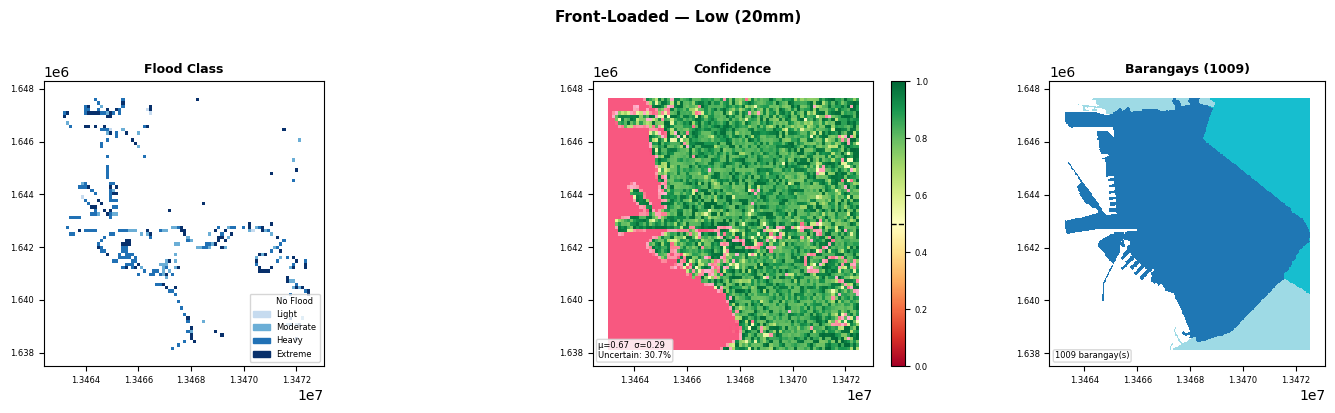

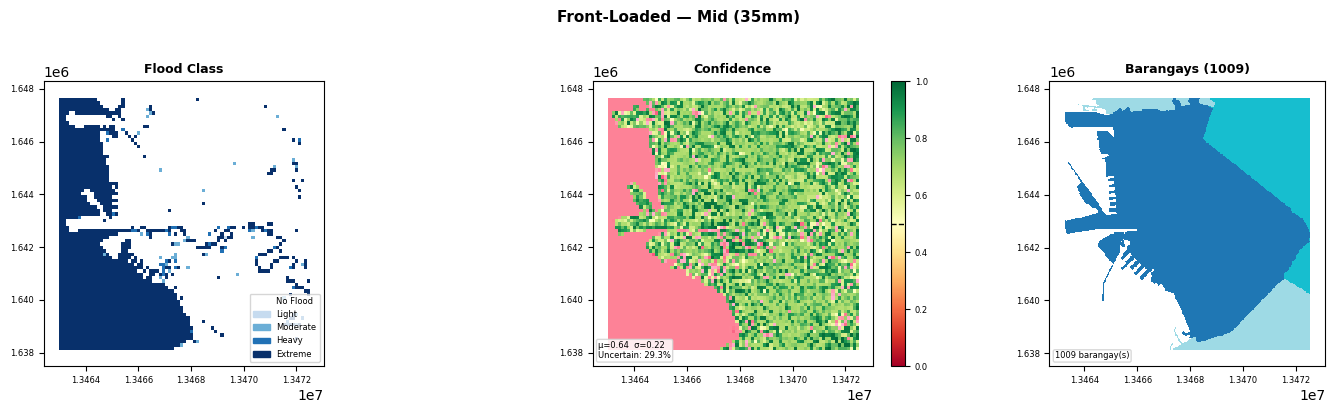

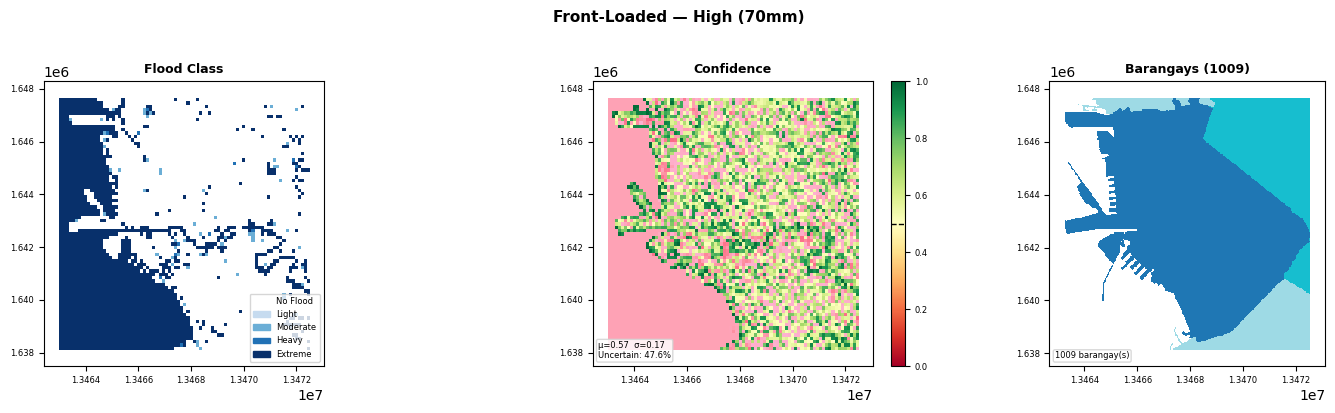

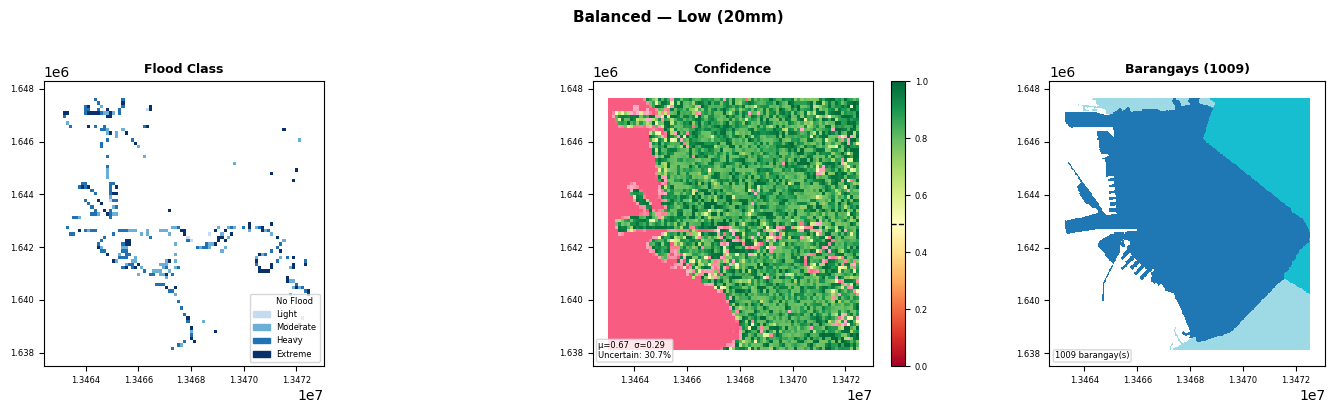

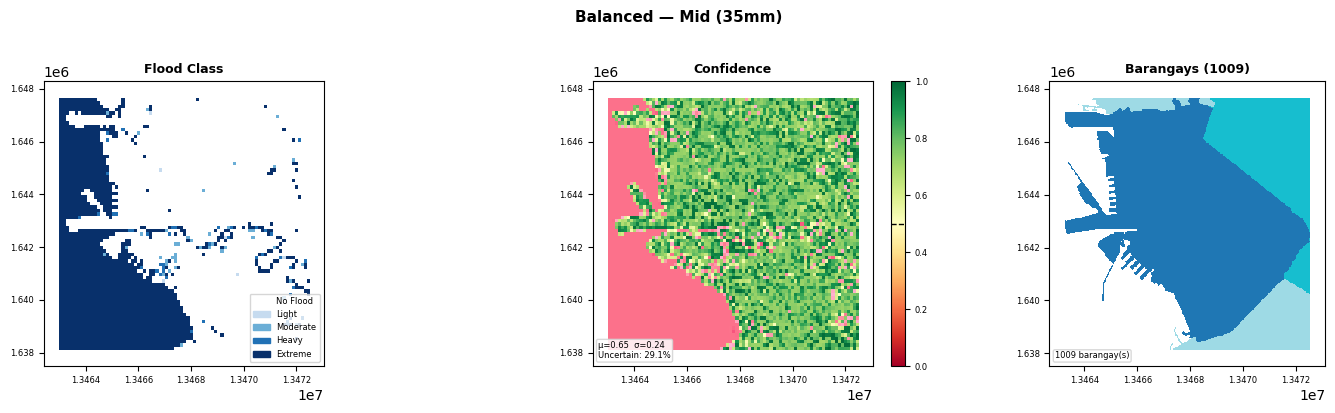

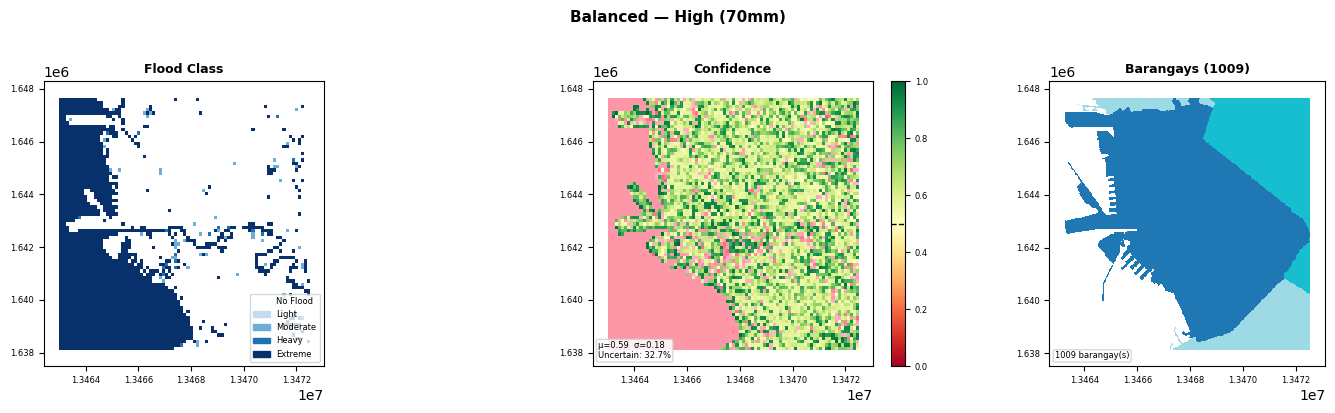

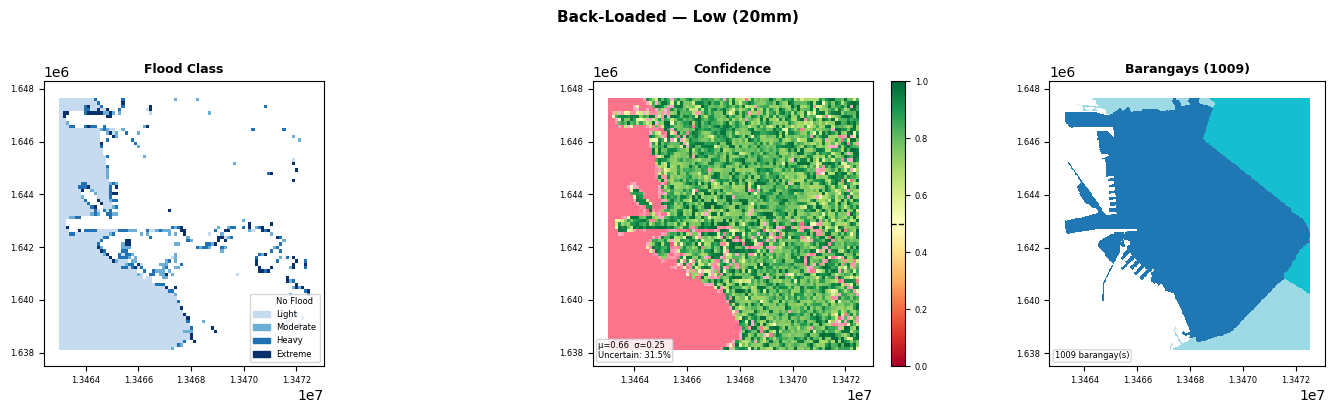

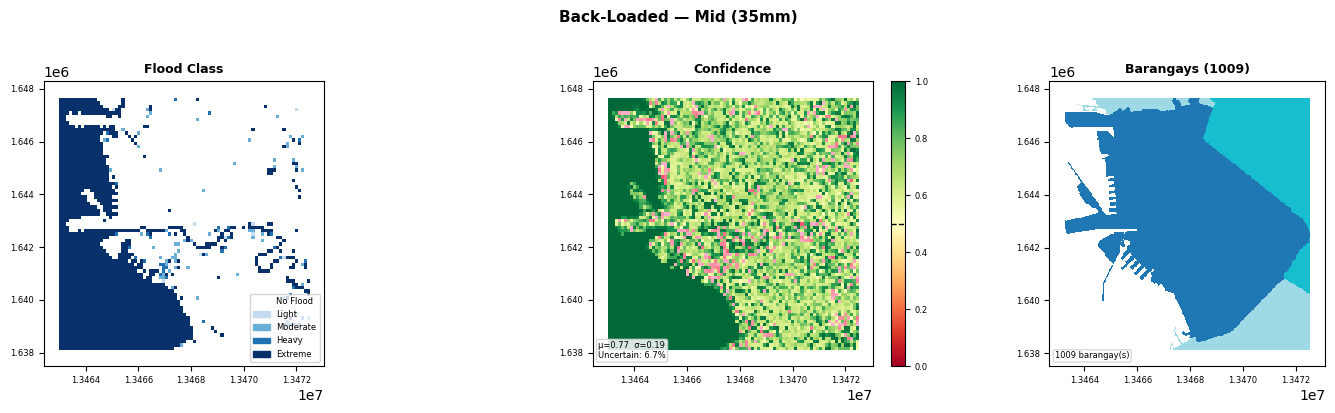

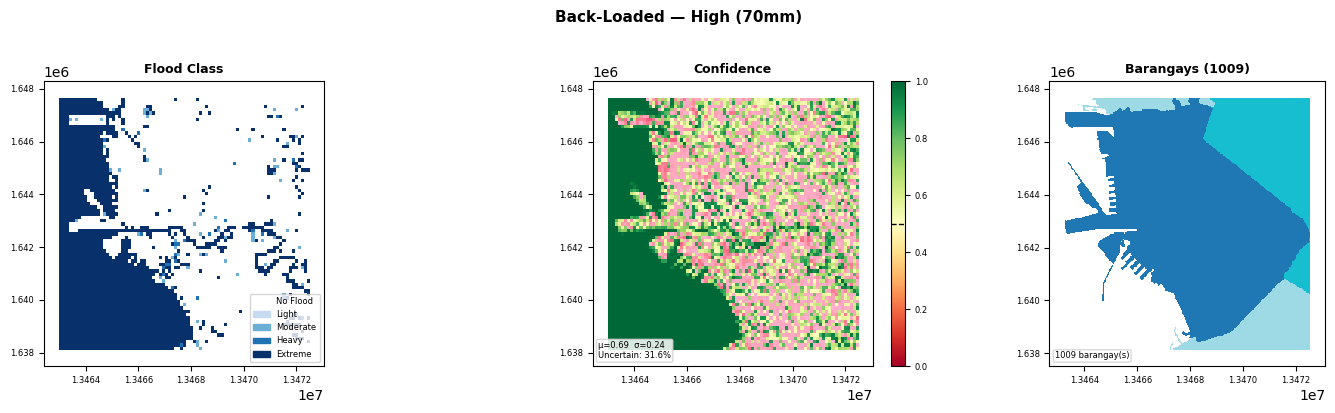

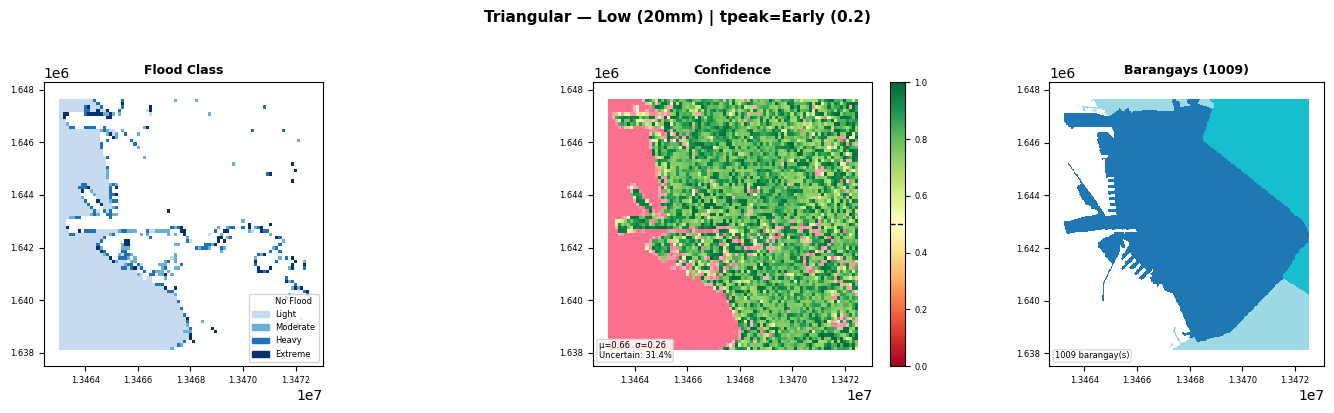

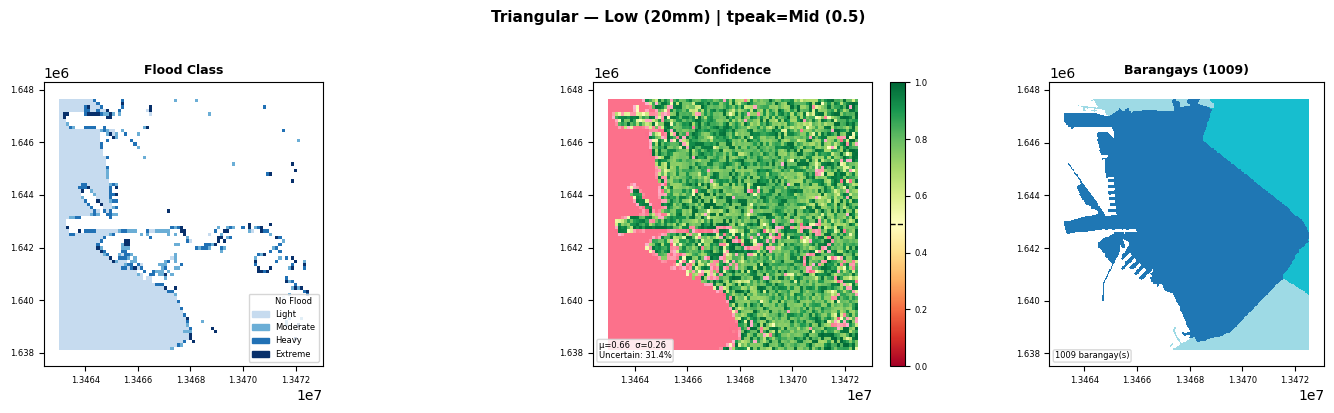

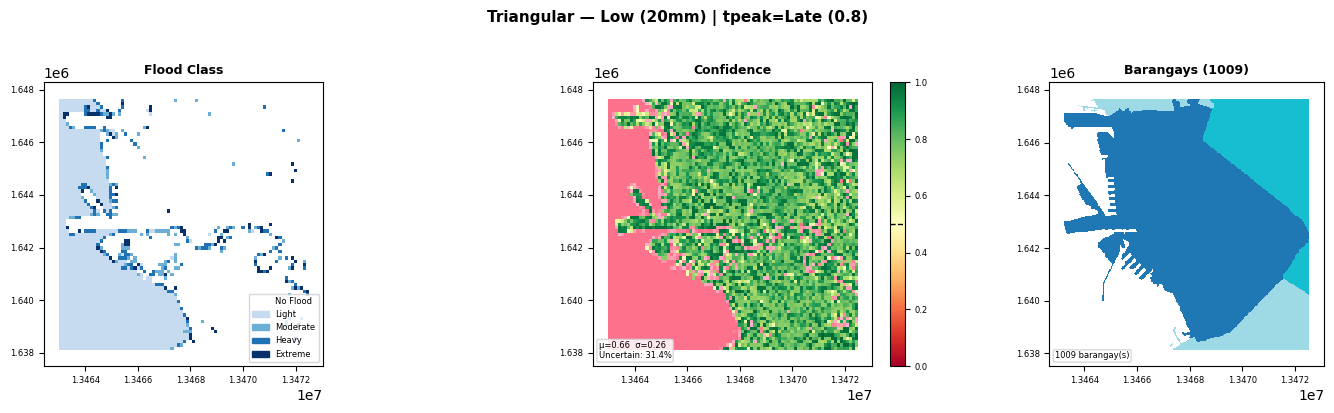

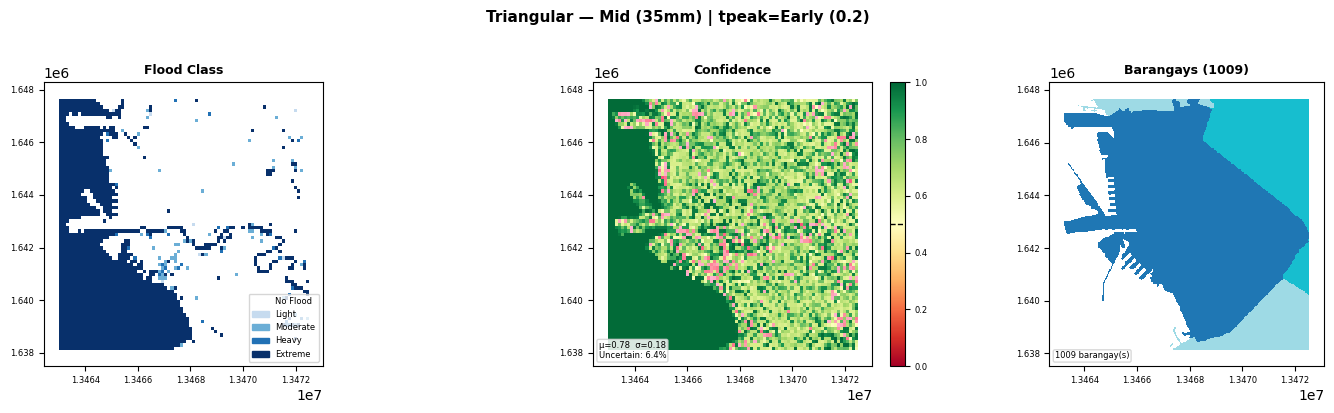

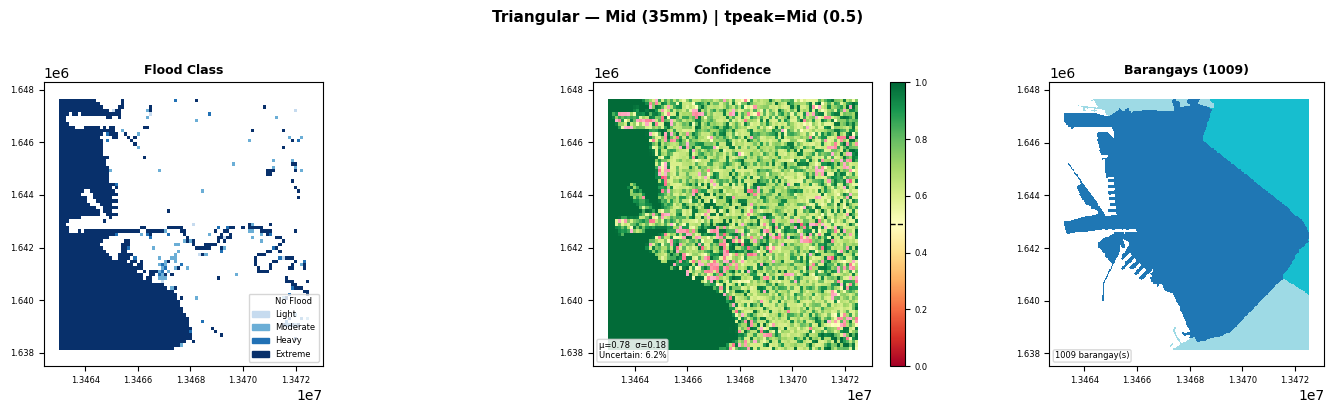

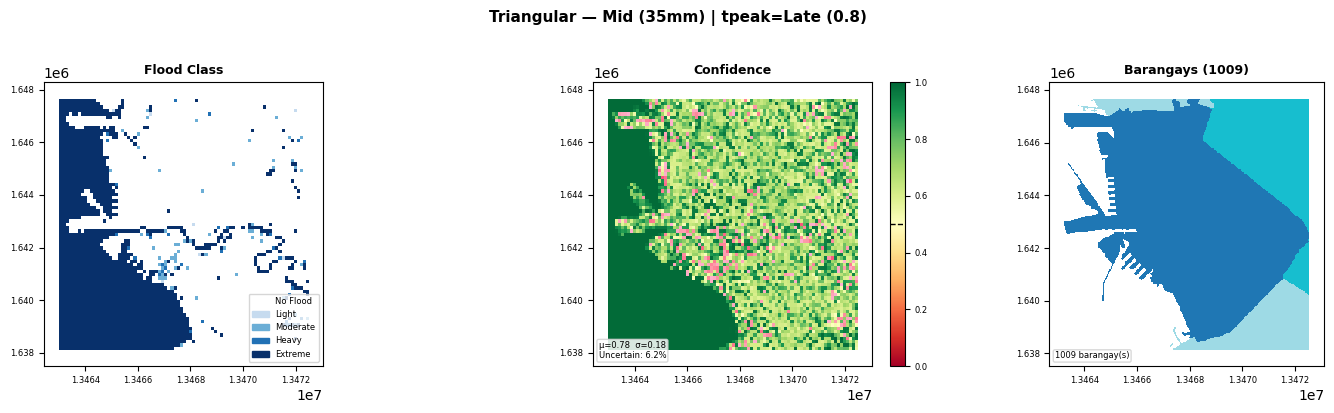

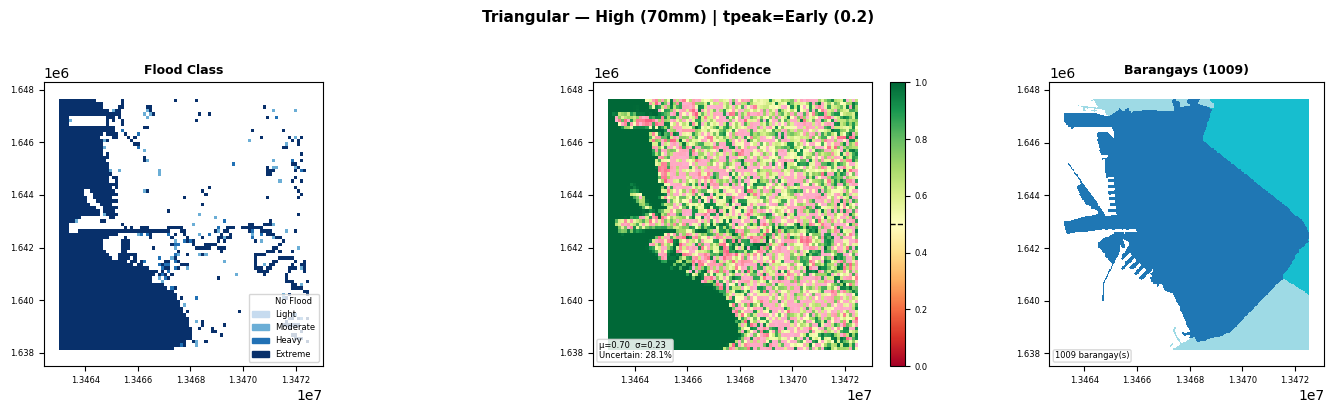

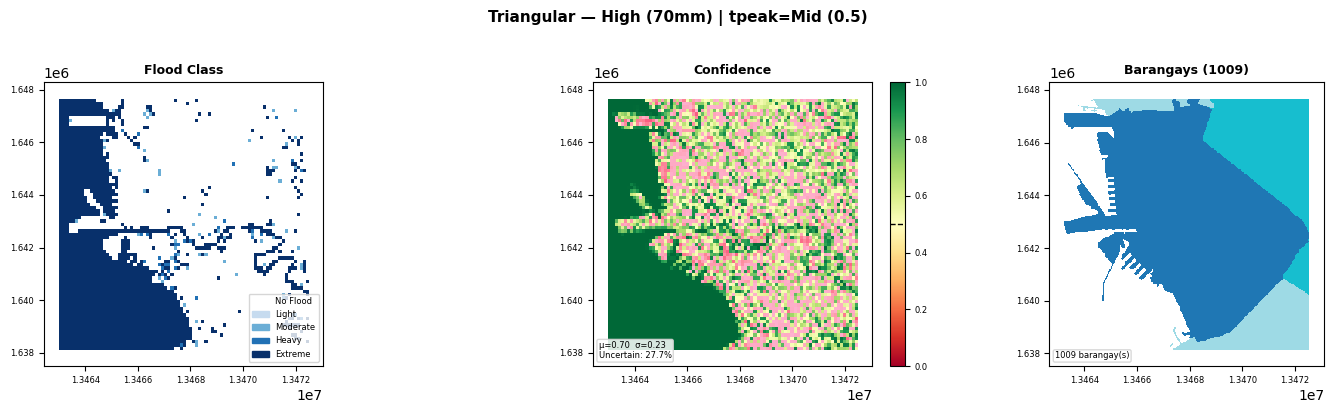

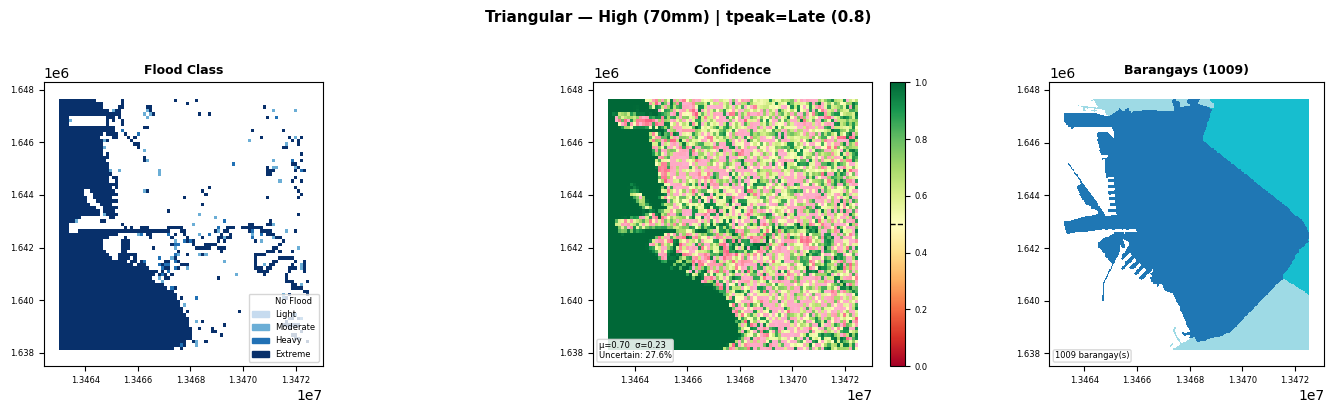

In [10]:
# ── Visualize all saved ablation TIFFs ───────────────────────────────────────

for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        slug  = f"{storm_type.replace('-','_')}_{depth}mm"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"{storm_type.title()} — {DEPTH_LABELS[depth]}"
        visualize_prediction_tiff(tif, title=title)
        plt.show()

for depth in DEPTHS:
    for tpeak in TPEAKS:
        slug  = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"Triangular — {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}"
        visualize_prediction_tiff(tif, title=title)
        plt.show()